In [2]:
%autoreload 2

In [3]:
%reload_ext autoreload
import os, sys, ast
import numpy as np
import pandas as pd
import seaborn as sns
import tifffile

import matplotlib.pyplot as plt
from matplotlib import gridspec, rcParams
from fish import Gafftopsail
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
import utils, barcode
path = ('C:/Data/Imaging/251224_overlap/fish5/')
rcParams['font.size'] = 10

In [4]:
#load atlas
template_path = "C:\Data\MapZBrainATLAS\T_AVG_HuCD.tif"
template = tifffile.imread(template_path)

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Zichen\AppData\Local\Temp\ipykernel_23184\4158968567.py:2: SyntaxWarning: invalid escape sequence '\D'
  template_path = "C:\Data\MapZBrainATLAS\T_AVG_HuCD.tif"


In [56]:
def plot_rainbow(stim_responses):
    region_list = [['prosencephalon_(forebrain)', 'mesencephalon_(midbrain)'], 'rhombencephalon_(hindbrain)']
    #region_list = ['i']
    fig = plt.figure(dpi=240, figsize=(20, 10))
    gs = gridspec.GridSpec(len(region_list), 4, figure=fig)
    ax_imshow_all = fig.add_subplot(gs[:, 0])

    #only plot visually responsive neurons that have been somewhat barrcoded
    barred = set(grating_responses.index[(grating_responses.filter(like="barred_").any(axis=1)) & (grating_responses["DSI2"] > 0)])
    barred_hist = set(grating_responses.index[(grating_responses.filter(like="barred_").any(axis=1)) & (grating_responses["DSI2"] > 0)])

    for i, r in enumerate(region_list):
        if type(r) == list:
            region_n = set(stim_responses.index[stim_responses['regions'].apply(lambda x: any(ri in x for ri in r))])
        else:
            region_n =set(stim_responses.index)#set(stim_responses.index[stim_responses['regions'].apply(lambda x: r in x)])#
        barred_r = list(region_n & barred)
        barred_hist_r = list(region_n & barred_hist)

        #manage figure space
        ax_polar_all = fig.add_subplot(gs[i, 1], polar = True)
        ax_polar_all.set_theta_offset(np.pi/2)
        ax_polar_all.set_ylim([i, 1])
        ax_polar_all.set_theta_direction(-1)
        ax_heat = fig.add_subplot(gs[i, 2], polar = True)
        ax_heat.set_theta_offset(np.pi/2)
        ax_heat.set_theta_direction(-1)

        ax_hist = fig.add_subplot(gs[i, 3])
        #
        # #color: tuned angles
        # colors = stim_responses.loc[barred_r, 'dir']
        # colors = [utils.angle_to_rgba(c, 1, 1) for c in colors]
        # #alpha: dsi
        # alphas = stim_responses.loc[barred_r, 'DSI2']
        # alphas = [i if not np.isnan(i) else 0 for i in alphas]
        # ax_imshow_all.scatter(stim_responses.loc[barred_r, 'xpos'], stim_responses.loc[barred_r, 'ypos'], c = colors, s = 1, alpha = np.clip(alphas, 0, 1), marker = '.')
        #
        # #plot vector plot
        # dirs_rad = np.deg2rad(stim_responses.loc[barred_r, 'dir'].values)
        # radii = stim_responses.loc[barred_r, 'DSI2'].values
        # ax_polar_all.scatter(dirs_rad, radii, c=colors, alpha=0.7, s=5, marker = '.')
        # ax_polar_all.set_ylim([0, 1])
        # ax_polar_all.set_axis_off()
        # #plot it across all neurons
        # ax_imshow_all.imshow(template[160], cmap = 'gray', vmax = 400)
        # ax_imshow_all.set_axis_off()
        #
        # #plot heatmap
        # theta_bins = np.linspace(-np.pi, np.pi, 73)
        # r_bins = np.linspace(0, 1, 10)
        # H, theta_edges, r_edges = np.histogram2d(dirs_rad, radii, bins=[theta_bins, r_bins])
        # H = H / H.sum() * 100
        # T, R = np.meshgrid(theta_edges, r_edges)
        # ax_heat.pcolormesh(T, R, H.T, vmin = 0, vmax = 0.3)
        # ax_heat.set_axis_off()
        #
        #plot histogram
        hist_data = stim_responses.loc[barred_hist_r]
        # bin DSI2 into 0.1 steps
        bins = np.arange(0, 1.1, 0.1)
        hist_data['DSI2'] = pd.to_numeric(hist_data['DSI2'], errors='coerce')
        hist_data = hist_data.dropna(subset=['DSI2'])
        hist_data['DSI_bin'] = pd.cut(hist_data['DSI2'], bins=bins, include_lowest=True)
        hist_data['DSI_bin'] = hist_data['DSI_bin'].apply(lambda x: x.left + (x.right - x.left)/2)
        # compute mean probability per bin for each fish
        bin_stats = hist_data.groupby(['DSI_bin', 'fish_id']).size().reset_index(name='count')
        bin_stats['prob'] = bin_stats.groupby('fish_id')['count'].transform(lambda x: x / x.sum())
        # plot mean across fish with confidence interval
        sns.lineplot(data=bin_stats,x='DSI_bin',y= 'prob', errorbar='sd',ax=ax_hist)
        ax_hist.set_ylim([0, .2])
        ax_hist.spines[['top', 'right']].set_visible(False)
    return fig

C:\Users\Zichen\AppData\Local\Temp\ipykernel_23184\4046013741.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = hist_data.groupby(['DSI_bin', 'fish_id']).size().reset_index(name='count')
C:\Users\Zichen\AppData\Local\Temp\ipykernel_23184\4046013741.py:23: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax_polar_all.set_ylim([i, 1])
C:\Users\Zichen\AppData\Local\Temp\ipykernel_23184\4046013741.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = hist_data.groupby(['DSI_bin', 'fish_id']).size().reset_index(name='cou

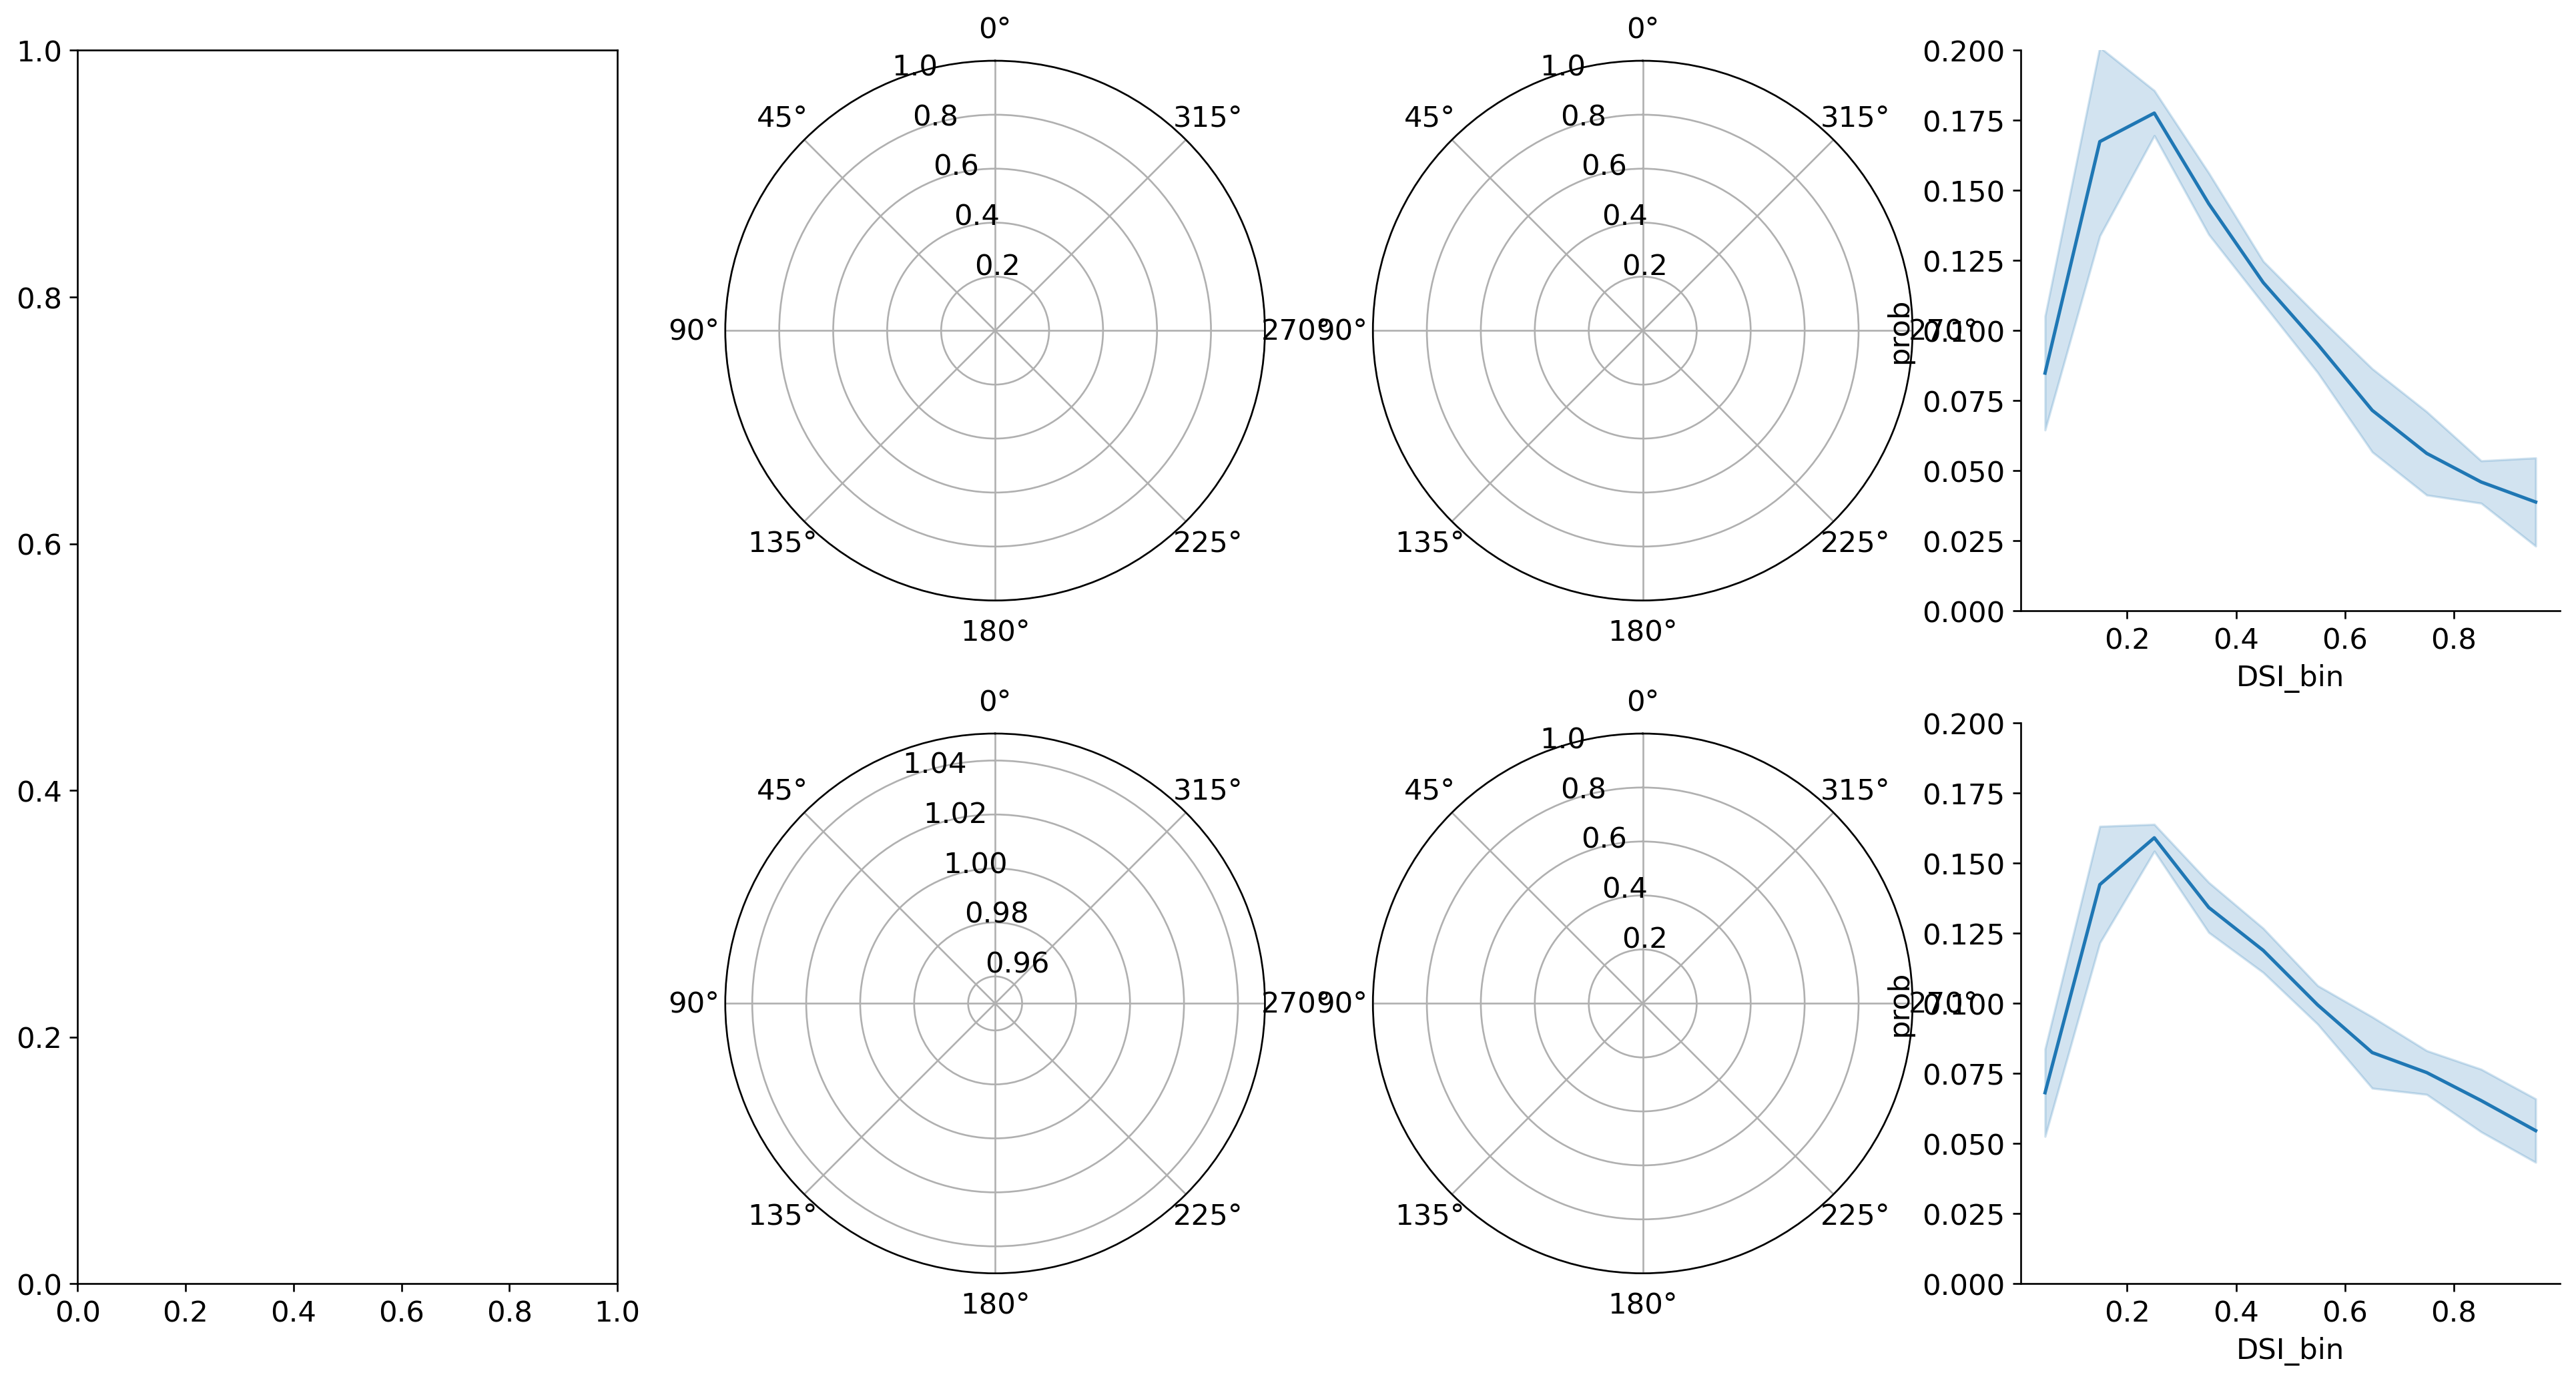

In [57]:
# paths = [r"C:\Data\Imaging\250912_overlap\fish3",
# r"C:\Data\Imaging\250912_overlap\fish2_2",
#          r"C:\Data\Imaging\250912_overlap\fish5_2",
#          r"C:\Data\Imaging\250912_overlap\fish9",
# r"C:\Data\Imaging\250912_overlap\fish7",
# r"C:\Data\Imaging\250912_overlap\fish8",
#          r"C:\Data\Imaging\250912_overlap\fish15",
# r"C:\Data\Imaging\250912_overlap\fish13",
# r"C:\Data\Imaging\250912_overlap\fish14"]
# paths =      [r"C:\Data\Imaging\251021_dotsweep\fish5_overlap",
#  r"C:\Data\Imaging\251021_dotsweep\fish4_overlap",
#  r"C:\Data\Imaging\251021_dotsweep\fish3_overlap",
paths = [   r"C:\Data\Imaging\251224_overlap\fish3_HB",
r"C:\Data\Imaging\251224_overlap\fish5",
r"C:\Data\Imaging\251224_overlap\fish5_HB",
r"C:\Data\Imaging\251224_overlap\fish1",
r"C:\Data\Imaging\251224_overlap\fish1_HB",
r"C:\Data\Imaging\251224_overlap\fish2",
r"C:\Data\Imaging\251224_overlap\fish2_HB",
r"C:\Data\Imaging\251224_overlap\fish3"]

grating_responses = []
for path in paths:
    grating_response = pd.read_csv(path + '//analyze_results//grating_responses_delayed.csv', index_col = 0)
    new_poses = []
    neuron_count = 0
    for plane in range(5):
        new_pos = pd.read_csv(path + f'//Imaging//plane_{plane}//Alignment//new_pos.csv', converters={"regions": ast.literal_eval})
        # stat = np.load(path + f'//Imaging//plane_{plane}//'+ 'stat.npy', allow_pickle=True)
        # avg_xpos = np.array([np.mean(cell['ypix']) for cell in stat])
        # avg_ypos = np.array([np.mean(cell['xpix']) for cell in stat])
        # avg_zpos = np.array([plane] * len(avg_xpos))
        # new_pos = pd.DataFrame(data = np.array([avg_xpos, avg_ypos, avg_zpos]).T,
        #                                    columns = ['xpos', 'ypos', 'zpos'],
        #                                    index = np.add(range(len(avg_xpos)), neuron_count))
        # neuron_count += len(avg_xpos)
        new_poses.append(new_pos)
    new_poses = pd.concat(new_poses, ignore_index = True)
    grating_response = pd.concat([grating_response, new_poses], ignore_index = False, axis = 1)
    grating_response.loc[:, 'fish_id'] = path
    grating_responses.append(grating_response)
grating_responses = pd.concat(grating_responses).reset_index()
fig = plot_rainbow(grating_responses)
plt.savefig(r"C:\Data\Imaging\251224_overlap\All_imaging//dsi_delayed.svg")
plt.show()
plt.close()

C:\Users\Zichen\AppData\Local\Temp\ipykernel_23184\4046013741.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = hist_data.groupby(['DSI_bin', 'fish_id']).size().reset_index(name='count')
C:\Users\Zichen\AppData\Local\Temp\ipykernel_23184\4046013741.py:23: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax_polar_all.set_ylim([i, 1])
C:\Users\Zichen\AppData\Local\Temp\ipykernel_23184\4046013741.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = hist_data.groupby(['DSI_bin', 'fish_id']).size().reset_index(name='cou

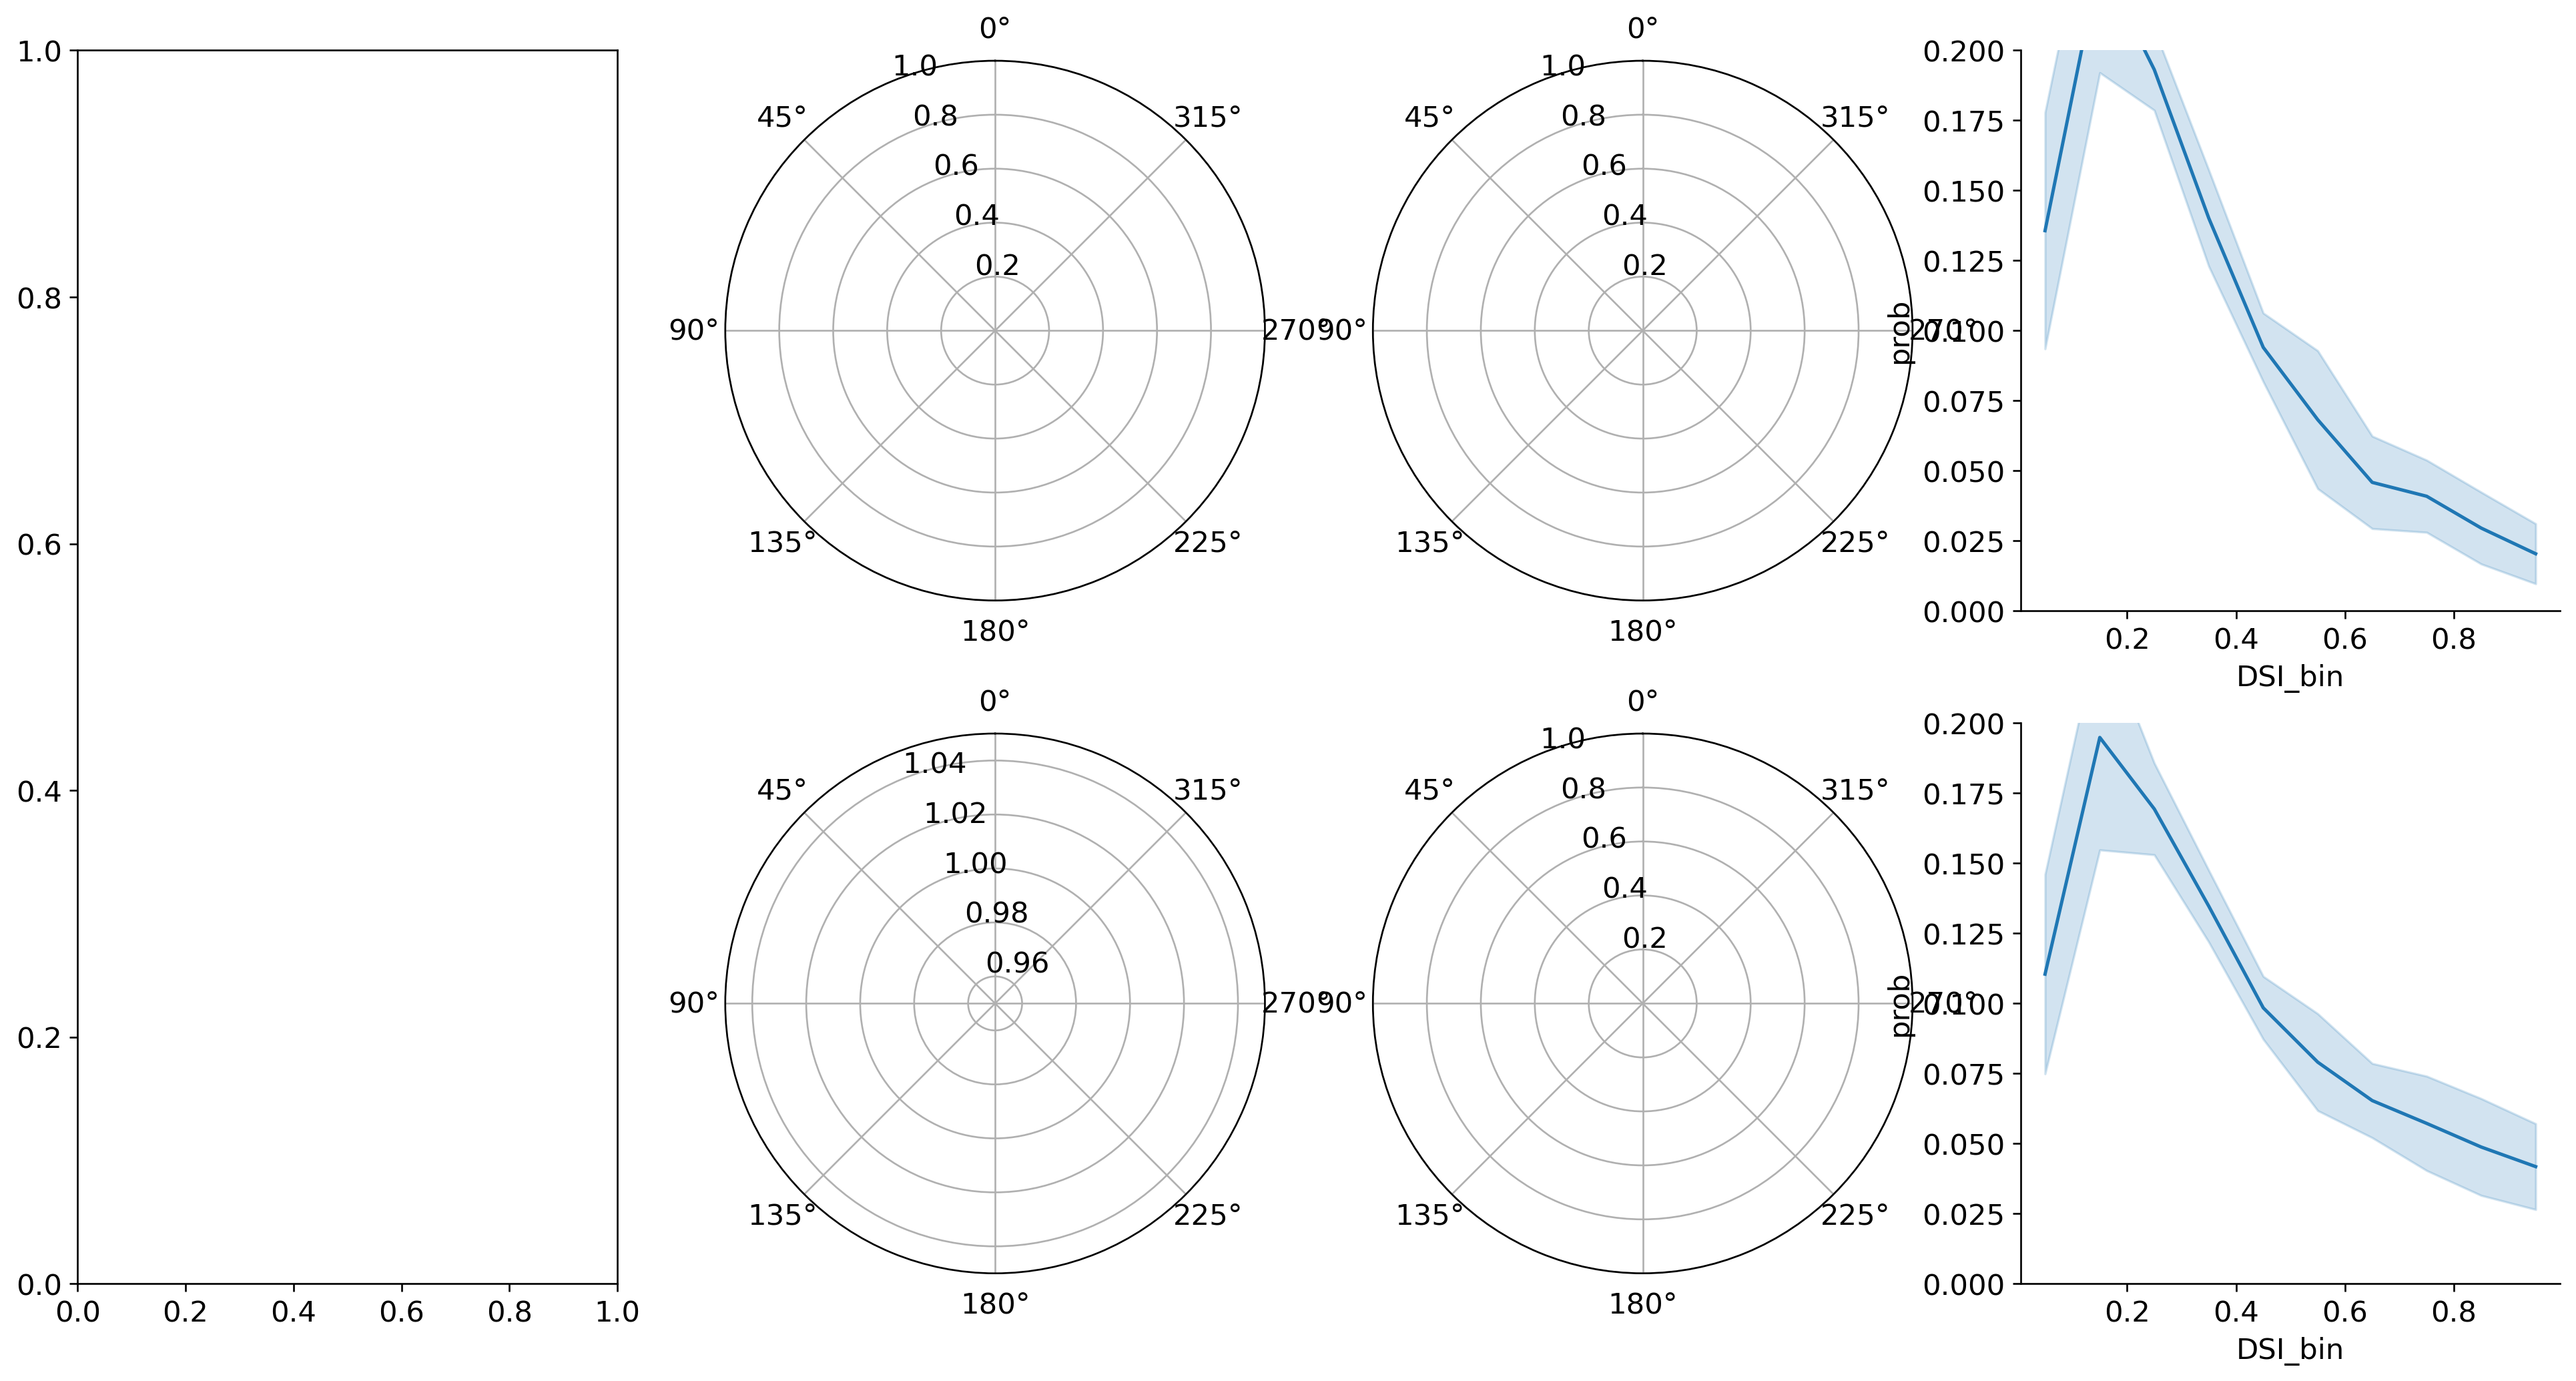

In [58]:
grating_responses = []
for path in paths:
    grating_response = pd.read_csv(path + '//analyze_results//dot_lgrating_responses_delayed.csv', index_col = 0)
    new_poses = []
    neuron_count = 0
    for plane in range(5):
        new_pos = pd.read_csv(path + f'//Imaging//plane_{plane}//Alignment//new_pos.csv', converters={"regions": ast.literal_eval})
        # stat = np.load(path + f'//Imaging//plane_{plane}//'+ 'stat.npy', allow_pickle=True)
        # avg_xpos = np.array([np.mean(cell['ypix']) for cell in stat])
        # avg_ypos = np.array([np.mean(cell['xpix']) for cell in stat])
        # avg_zpos = np.array([plane] * len(avg_xpos))
        # new_pos = pd.DataFrame(data = np.array([avg_xpos, avg_ypos, avg_zpos]).T,
        #                                    columns = ['xpos', 'ypos', 'zpos'],
        #                                    index = np.add(range(len(avg_xpos)), neuron_count))
        # neuron_count += len(avg_xpos)
        new_poses.append(new_pos)
    new_poses = pd.concat(new_poses, ignore_index = True)
    grating_response = pd.concat([grating_response, new_poses], ignore_index = False, axis = 1)
    grating_response.loc[:, 'fish_id'] = path
    grating_responses.append(grating_response)
grating_responses = pd.concat(grating_responses).reset_index()
fig = plot_rainbow(grating_responses)
plt.savefig(r"C:\Data\Imaging\251224_overlap\All_imaging//dsi_dotl_delayed.svg")

plt.show()
plt.close()

C:\Users\Zichen\AppData\Local\Temp\ipykernel_23184\4046013741.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = hist_data.groupby(['DSI_bin', 'fish_id']).size().reset_index(name='count')
C:\Users\Zichen\AppData\Local\Temp\ipykernel_23184\4046013741.py:23: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax_polar_all.set_ylim([i, 1])
C:\Users\Zichen\AppData\Local\Temp\ipykernel_23184\4046013741.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = hist_data.groupby(['DSI_bin', 'fish_id']).size().reset_index(name='cou

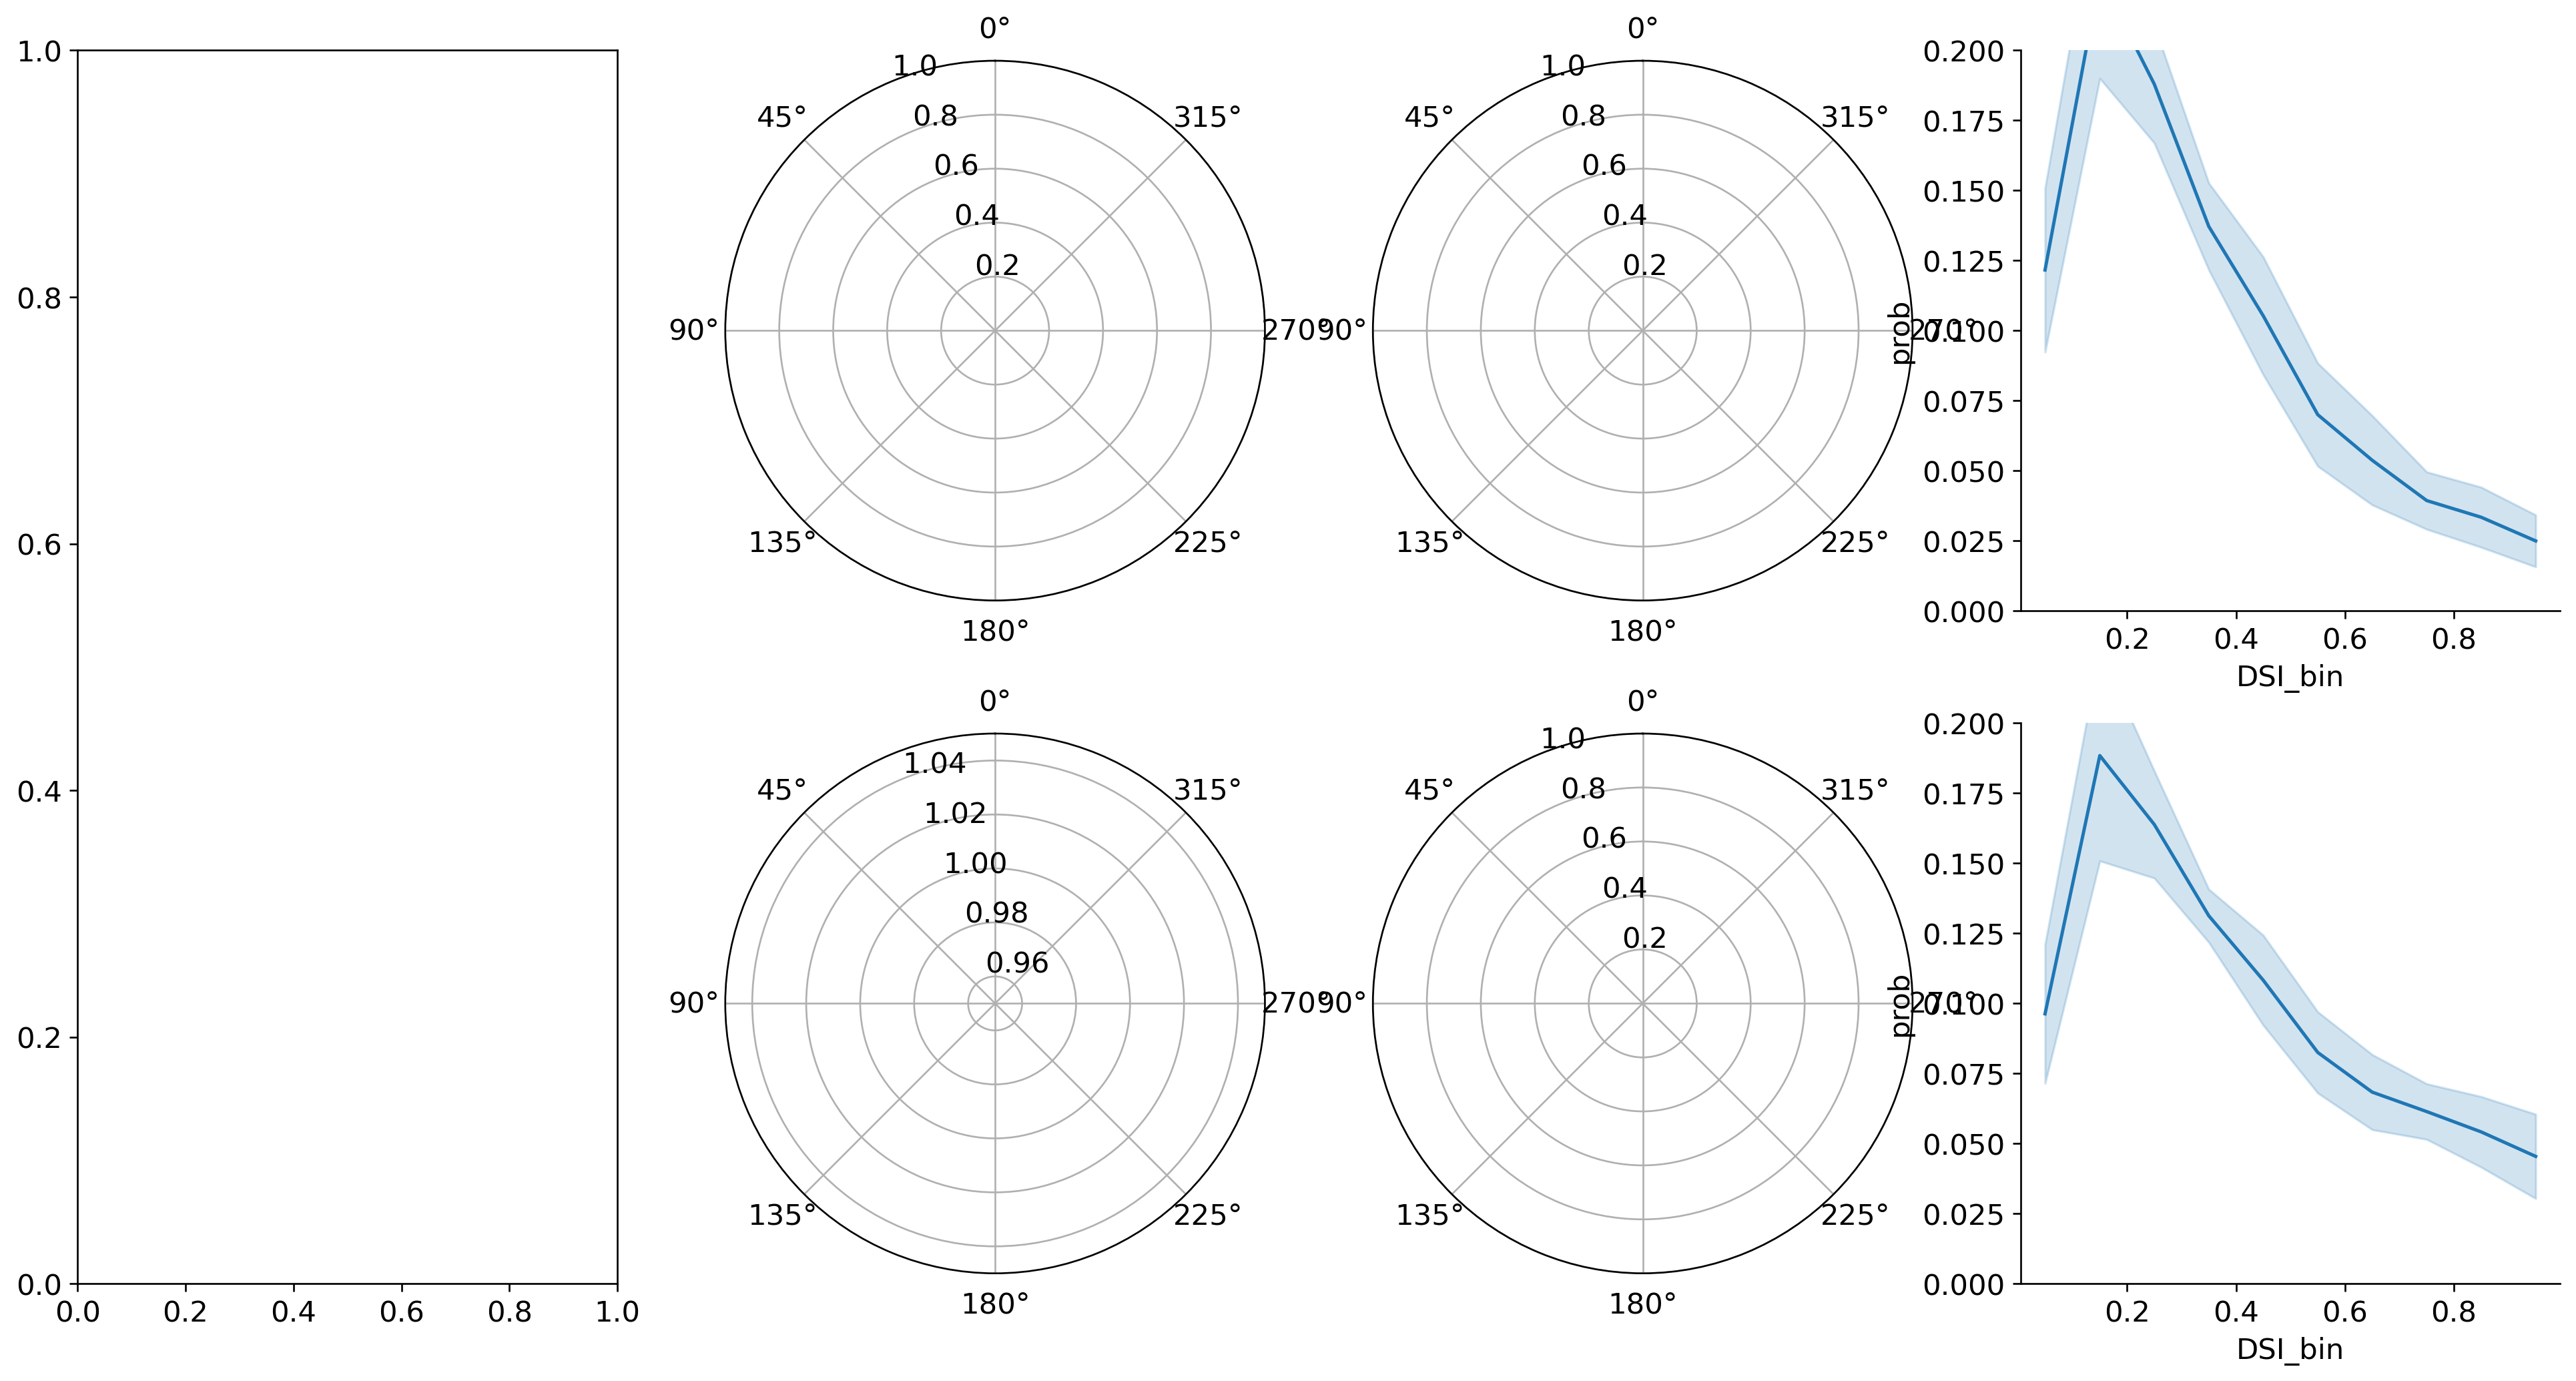

In [59]:
grating_responses = []
for path in paths:
    grating_response = pd.read_csv(path + '//analyze_results//dot_rgrating_responses_delayed.csv', index_col = 0)
    new_poses = []
    neuron_count = 0
    for plane in range(5):
        new_pos = pd.read_csv(path + f'//Imaging//plane_{plane}//Alignment//new_pos.csv', converters={"regions": ast.literal_eval})
        # stat = np.load(path + f'//Imaging//plane_{plane}//'+ 'stat.npy', allow_pickle=True)
        # avg_xpos = np.array([np.mean(cell['ypix']) for cell in stat])
        # avg_ypos = np.array([np.mean(cell['xpix']) for cell in stat])
        # avg_zpos = np.array([plane] * len(avg_xpos))
        # new_pos = pd.DataFrame(data = np.array([avg_xpos, avg_ypos, avg_zpos]).T,
        #                                    columns = ['xpos', 'ypos', 'zpos'],
        #                                    index = np.add(range(len(avg_xpos)), neuron_count))
        # neuron_count += len(avg_xpos)
        new_poses.append(new_pos)
    new_poses = pd.concat(new_poses, ignore_index = True)
    grating_response = pd.concat([grating_response, new_poses], ignore_index = False, axis = 1)
    grating_response.loc[:, 'fish_id'] = path
    grating_responses.append(grating_response)
grating_responses = pd.concat(grating_responses).reset_index()
fig = plot_rainbow(grating_responses)
plt.savefig(r"C:\Data\Imaging\251224_overlap\All_imaging//dsi_dotr_delayed.svg")
plt.show()
plt.close()